# SABR interpolation on cleaned historical data

Same **dataset** as in `docs/sabr_interpolation.md` (processed parquet from `data_pipeline.py` → `clean_data` → `processed.parquet`). Pick any **evaluation** grids `k_grid` and `tau_grid` for the dense surface; they do not need to match a kernel smoother.

Interpolation follows the repo SABR path: **per-expiry** `(α, ρ, ν)` with fixed `β`, then **`implied_vol_surface_from_calibrated_slices`** (Hagan lognormal `sabr_lognormal_iv` on each grid point), wired for historic quotes by **`build_historical_sabr_surface`** (`filter_day_for_surface`, expiry grouping, `m = exp(k)` for moneyness).

Run with `pip install -e .` from the repo root.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from implied_volatility_diffusion.data.historical_data_smoothing_interpolation import (
    load_cleaned_data,
    plot_smile,
    plot_surface_3d,
)
from implied_volatility_diffusion.data.historical_sabr_interpolation import (
    build_historical_sabr_surface,
)

## Load cleaned data

Default path matches `config/data_pipeline_config.yaml` (`processed_output_path`).

In [2]:
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd

processed_data_path = repo_root / "data" / "processed" / "processed.parquet"
df = load_cleaned_data(processed_data_path)

sample_date = pd.Timestamp("2021-06-17")
day = df[df["quote_date"] == sample_date].copy()
print("cleaned dataset:", processed_data_path)
print("sample_date:", sample_date, "rows (this day):", len(day))

r, q, beta = 0.03, 0.0, 0.5

cleaned dataset: /Users/wendy/Documents/Finance_Engineering/DeepLeariningonOptions/implied-volatility-diffusion-transformer/data/processed/processed.parquet
sample_date: 2021-06-17 00:00:00 rows (this day): 14699


## SABR dense surface (choose your own evaluation grids)

Below: log-moneyness `k` and maturity `tau` axes for **model evaluation only** (same spirit as `docs/sabr_interpolation.md` § full surface / historic example; change resolution and ranges as you like).

In [3]:
k_grid = np.linspace(-0.2, 0.2, 41)
tau_grid = np.linspace(0.05, 1.0, 24)
KGRID, TAUGRID = np.meshgrid(k_grid, tau_grid, indexing="ij")

sabr_out = build_historical_sabr_surface(day, k_grid, tau_grid, r=r, q=q, beta=beta)
Z_sabr = sabr_out.surface

print("SABR — filtered rows:", len(sabr_out.day_sub), "surface shape:", Z_sabr.shape)
print("finite:", np.isfinite(Z_sabr).sum(), "/", Z_sabr.size, "spot:", sabr_out.spot)
print("(alpha, rho, nu) per expiry:\n", sabr_out.calibrated_params)

SABR — filtered rows: 12812 surface shape: (41, 24)
finite: 984 / 984 spot: 4221.88
(alpha, rho, nu) per expiry:
 [[ 3.60774548 -0.46403162 12.14187037]
 [ 4.82173438 -0.53363271  9.55009056]
 [ 6.10292691 -0.51142173  7.41873927]
 [ 6.05210371 -0.52693167  6.19152411]
 [ 6.63298359 -0.29733813  5.5480591 ]
 [ 5.61716715 -0.16981533  5.96876418]
 [ 6.36746326 -0.48735936  5.00612738]
 [ 6.474232   -0.55973258  4.9181616 ]
 [ 6.91433863 -0.61023275  4.50531854]
 [ 6.90983343 -0.62824668  4.22174734]
 [ 7.10772927 -0.62981855  4.05764958]
 [ 6.87966129 -0.68991918  4.244767  ]
 [ 7.18743741 -0.71327162  3.9628418 ]
 [ 7.37266129 -0.69954729  3.66710198]
 [ 7.50781596 -0.70468754  3.45400884]
 [ 7.93650624 -0.7009428   3.0772788 ]
 [ 8.37232551 -0.66556307  2.40006131]
 [ 8.74225664 -0.67710407  2.20915421]
 [ 9.18053337 -0.67902545  1.88104592]
 [ 9.3767801  -0.6779248   1.74796066]
 [ 9.57487485 -0.66163674  1.63483706]
 [ 9.80870838 -0.68295379  1.53439482]
 [ 9.87153049 -0.65444371  1

## Plots

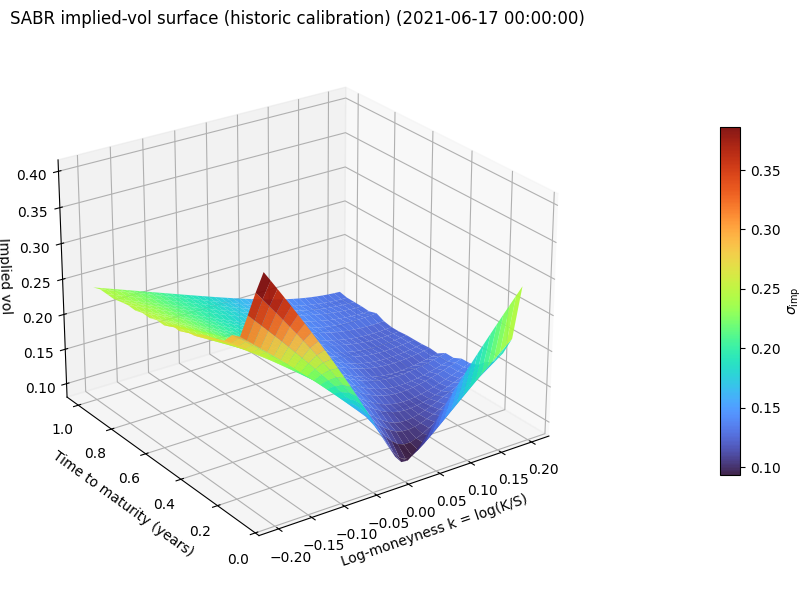

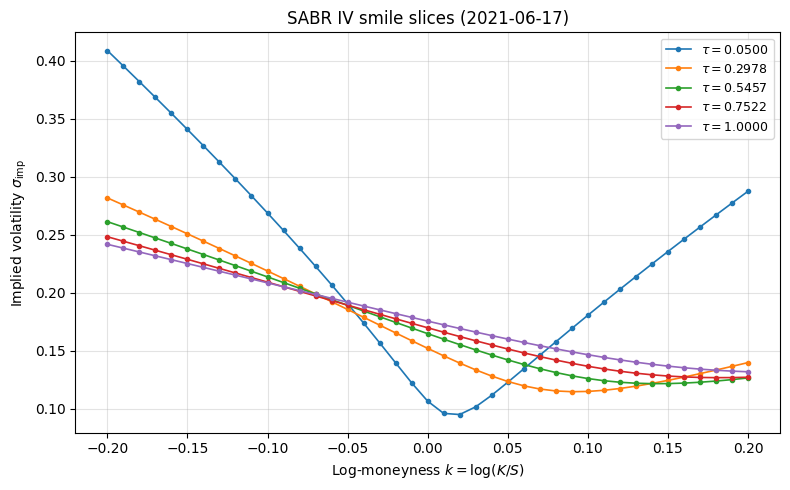

In [4]:
plot_surface_3d(
    KGRID,
    TAUGRID,
    Z_sabr,
    sample_date,
    title="SABR implied-vol surface (historic calibration)",
)

plot_smile(
    k_grid,
    tau_grid,
    Z_sabr,
    sample_date,
    title="SABR IV smile slices",
)